# Campus Walk — Heel-Strike Loading Rate + GPS Map

Runs the full **loading-rate pipeline** (from `load_rate_fixed_v7`) on a single
multi-surface campus walk (`Kristian_dry_0425.csv`) and maps every detected
heel-strike onto the GPS route (`activity_22645980458.gpx`).

### What loading rate measures
Loading rate = pressure rise at the heel from **initial contact** to the
**heel-strike peak**, divided by the time between those two events:

```
LR = (peak_pressure - contact_pressure) / (peak_time - contact_time)   [pressure units / s]
```

A **high LR** = fast, steep heel load (harder surface or more impact-aggressive gait).  
A **low LR** = gradual, compliant heel load (softer surface or cushioned strike).

### Algorithm (v7 — two-sensor average, window-aligned)
Both heel sensors (`pressure_08` and `pressure_11`) share the same step-window
boundaries (detected from their **summed** signal). Per-sensor LR is averaged
across both sensors, aligned by `window_id` so contact-time differences between
sensors never cause a step to be silently dropped.

### Outputs
| File | Contents |
|---|---|
| `campus_loading_rates.csv` | Per-step LR with GPS coords |
| `campus_lr_map.html` | Route coloured by LR + per-step popups |
| `campus_lr_detail_map.html` | Right / left foot as toggleable layers |

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import find_peaks, savgol_filter
import xml.etree.ElementTree as ET
import folium
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Libraries loaded')
print(f'  folium {folium.__version__}')

Libraries loaded
  folium 0.20.0


## Cell 2 — Configuration

In [2]:
CSV_PATH = 'Kristian_dry_0425.csv'
GPX_PATH = 'activity_22645980458.gpx'

HEEL_SENSORS     = ['pressure_08', 'pressure_11']

# Step-window detection
SMOOTH_WIN    = 11
SMOOTH_POLY   = 2
BIG_PEAK_DIST = 50
BIG_PEAK_PROM = 200
BIG_PEAK_HT   = 500

# Loading-rate extraction
HILL_WINDOW = 10   # samples to search for heel-strike peak (~160 ms)
MIN_DP      = 5    # min pressure rise — keeps weak left-foot signal

GPS_TOLERANCE_MS = 5000   # max +-5 s for GPS match

FOOT_COLORS = {'right': '#1F77B4', 'left': '#FF7F0E'}

print('Configuration ready.')
print(f'  Hill window : {HILL_WINDOW} samples = {HILL_WINDOW*4} ms')
print(f'  Min dp      : {MIN_DP}')

Configuration ready.
  Hill window : 10 samples = 40 ms
  Min dp      : 5


## Cell 3 — Load & Pre-process Insole Data

In [3]:
def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df

raw    = pd.read_csv(CSV_PATH, low_memory=False)
before = len(raw)
raw    = raw[raw['corrupt'] == 0].copy()

right_df = preprocess(raw[raw['sole_id'] == 1])
left_df  = preprocess(raw[raw['sole_id'] == 2])

duration_s = (raw['timestamp'].max() - raw['timestamp'].min()) / 1000
print(f'Insole data: {len(raw):,} rows  ({before - len(raw)} corrupt removed)')
print(f'  Duration : {duration_s:.1f} s  ({duration_s/60:.2f} min)')
print(f'  RIGHT    : {len(right_df):,} rows | {right_df["time_sec"].iloc[-1]:.1f} s')
print(f'  LEFT     : {len(left_df):,} rows | {left_df["time_sec"].iloc[-1]:.1f} s')

Insole data: 51,267 rows  (0 corrupt removed)
  Duration : 410.1 s  (6.84 min)
  RIGHT    : 25,633 rows | 410.1 s
  LEFT     : 25,634 rows | 410.1 s


## Cell 4 — Load & Parse GPX Track

In [4]:
def parse_gpx(path):
    """
    Parse GPX into a DataFrame with lat, lon, unix_ms.
    unix_ms shares the same epoch-millisecond clock as the insole timestamp column.
    """
    tree = ET.parse(path)
    root = tree.getroot()
    ns   = {'gpx': 'http://www.topografix.com/GPX/1/1'}
    rows = []
    for trkpt in root.findall('.//gpx:trkpt', ns):
        lat = float(trkpt.get('lat'))
        lon = float(trkpt.get('lon'))
        dt  = pd.to_datetime(trkpt.find('gpx:time', ns).text.strip(), utc=True)
        rows.append({'lat': lat, 'lon': lon, 'dt': dt,
                     'unix_ms': int(dt.value // 1_000_000)})
    return pd.DataFrame(rows)

gpx_df = parse_gpx(GPX_PATH)
gpx_s  = (gpx_df['unix_ms'].max() - gpx_df['unix_ms'].min()) / 1000
print(f'GPX: {len(gpx_df)} points | {gpx_s:.1f} s')
print(f'  Start : {gpx_df["dt"].iloc[0]}')
print(f'  End   : {gpx_df["dt"].iloc[-1]}')

overlap = (min(raw['timestamp'].max(), gpx_df['unix_ms'].max())
         - max(raw['timestamp'].min(), gpx_df['unix_ms'].min()))
print(f'\nTimestamp overlap: {overlap/1000:.1f} s  ->  {"OK" if overlap > 0 else "NO OVERLAP"}')

GPX: 440 points | 439.0 s
  Start : 2026-04-24 19:09:08+00:00
  End   : 2026-04-24 19:16:27+00:00

Timestamp overlap: 409.1 s  ->  OK


## Cell 5 — Timestamp Alignment Chart

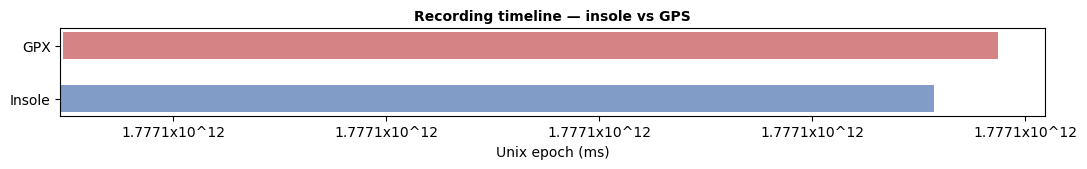

In [5]:
fig, ax = plt.subplots(figsize=(11, 1.8))
for label, (s, e), color in [
    ('Insole', (raw['timestamp'].min(), raw['timestamp'].max()), '#4C72B0'),
    ('GPX',   (gpx_df['unix_ms'].min(), gpx_df['unix_ms'].max()), '#C44E52'),
]:
    ax.barh(label, e - s, left=s, height=0.5, color=color, alpha=0.7)
ax.set_xlabel('Unix epoch (ms)')
ax.set_title('Recording timeline — insole vs GPS', fontsize=10, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:.4f}x10^12'))
plt.tight_layout()
plt.savefig('timeline_check.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 6 — Loading-Rate Extraction Functions

Faithful port of the v7 algorithm with one addition: `contact_timestamp`
(raw Unix-ms of the heel-contact sample) is propagated through the
averaging step so every step row can be GPS-matched by time.

In [6]:
def find_step_windows(df, sensors=HEEL_SENSORS):
    """
    Detect stance peaks from the SUMMED signal of both heel sensors.
    Using the sum gives both sensors identical window boundaries.
    """
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in sensors if s in df.columns
    )
    n  = len(y_comb)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY:
        sw = SMOOTH_POLY + 3 + (1 if (SMOOTH_POLY + 3) % 2 == 0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw,
                         polyorder=min(SMOOTH_POLY, sw - 1))
    peaks, _ = find_peaks(y_sm, distance=BIG_PEAK_DIST,
                           prominence=BIG_PEAK_PROM, height=BIG_PEAK_HT)
    return peaks


def extract_lr_per_sensor(df, sensor_col, big_peaks, foot_label,
                           time_col='time_sec'):
    """
    Per-sensor loading-rate extraction.
    contact   = argmin of raw signal in each inter-peak window
    hill_peak = first local max within HILL_WINDOW samples of contact
    LR        = pressure_rise / time_to_peak
    window_id is stored for cross-sensor alignment.
    contact_timestamp carries the raw Unix-ms for GPS matching.
    """
    df = df.copy().reset_index(drop=True)
    df[time_col]   = pd.to_numeric(df[time_col],   errors='coerce')
    df[sensor_col] = pd.to_numeric(df[sensor_col], errors='coerce')
    df = df.dropna(subset=[time_col, sensor_col]).reset_index(drop=True)

    t = df[time_col].to_numpy(dtype=float)
    y = df[sensor_col].to_numpy(dtype=float)
    n = len(y)
    if n < 20 or len(big_peaks) < 2:
        return pd.DataFrame(), df, np.array([]), np.array([])

    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY:
        sw = SMOOTH_POLY + 3 + (1 if (SMOOTH_POLY + 3) % 2 == 0 else 0)
    y_s = savgol_filter(y, window_length=sw, polyorder=min(SMOOTH_POLY, sw - 1))
    df[f'{sensor_col}_smooth'] = y_s

    results, contact_idxs, hill_idxs = [], [], []

    for i in range(len(big_peaks) - 1):
        p1, p2  = big_peaks[i], big_peaks[i + 1]
        c_local = int(np.argmin(y[p1:p2]))
        c_idx   = p1 + c_local

        end   = min(p2, c_idx + HILL_WINDOW)
        seg   = y[c_idx:end + 1]
        lp, _ = find_peaks(seg, prominence=1)
        h_local = lp[0] if len(lp) else int(np.argmax(seg[1:])) + 1
        h_idx   = c_idx + h_local

        dt = t[h_idx] - t[c_idx]
        dp = y[h_idx] - y[c_idx]
        if dt <= 0 or dp < MIN_DP:
            continue

        results.append({
            'foot'              : foot_label,
            'sensor'            : sensor_col,
            'window_id'         : i,
            'contact_time_sec'  : t[c_idx],
            'peak_time_sec'     : t[h_idx],
            'contact_pressure'  : y[c_idx],
            'peak_pressure'     : y[h_idx],
            'time_to_peak_sec'  : dt,
            'pressure_rise'     : dp,
            'loading_rate'      : dp / dt,
            'contact_timestamp' : int(df.iloc[c_idx]['timestamp']),
        })
        contact_idxs.append(c_idx)
        hill_idxs.append(h_idx)

    return (pd.DataFrame(results), df,
            np.array(contact_idxs), np.array(hill_idxs))


def extract_loading_rate(df, foot_label):
    """
    Full pipeline for one foot:
    1. Find shared windows from combined heel signal
    2. Extract per-sensor LR with those windows
    3. Average across sensors aligned by window_id
    Only steps seen by BOTH sensors are kept (n_sensors == 2).
    """
    big_peaks  = find_step_windows(df)
    per_sensor = {}
    for sensor in HEEL_SENSORS:
        res, plot_df, contacts, hills = extract_lr_per_sensor(
            df, sensor, big_peaks, foot_label)
        per_sensor[sensor] = (res, plot_df, contacts, hills)

    all_res = pd.concat([v[0] for v in per_sensor.values()], ignore_index=True)
    if all_res.empty:
        return pd.DataFrame(), per_sensor

    avg_res = (
        all_res
        .groupby(['foot', 'window_id'], as_index=False)
        .agg(
            contact_time_sec  = ('contact_time_sec',  'mean'),
            peak_time_sec     = ('peak_time_sec',     'mean'),
            contact_pressure  = ('contact_pressure',  'mean'),
            peak_pressure     = ('peak_pressure',     'mean'),
            time_to_peak_sec  = ('time_to_peak_sec',  'mean'),
            pressure_rise     = ('pressure_rise',     'mean'),
            loading_rate      = ('loading_rate',      'mean'),
            n_sensors         = ('sensor',            'count'),
            contact_timestamp = ('contact_timestamp', 'mean'),
        )
        .pipe(lambda d: d[d['n_sensors'] == len(HEEL_SENSORS)])
        .drop(columns='window_id')
        .reset_index(drop=True)
    )
    avg_res['contact_timestamp'] = avg_res['contact_timestamp'].round().astype(int)
    avg_res['step_id'] = range(1, len(avg_res) + 1)
    return avg_res, per_sensor


print('Loading-rate functions defined')

Loading-rate functions defined


## Cell 7 — Run Extraction on Both Feet

In [7]:
results = {}
for foot_label, foot_df in [('right', right_df), ('left', left_df)]:
    avg_res, per_sensor = extract_loading_rate(foot_df, foot_label)
    results[foot_label] = (avg_res, per_sensor)
    lr = avg_res['loading_rate']
    print(f'{foot_label.upper():5s} -> {len(avg_res):4d} steps | '
          f'mean LR = {lr.mean():6.0f}  '
          f'std = {lr.std():5.0f}  '
          f'min = {lr.min():5.0f}  '
          f'max = {lr.max():5.0f}  [pressure units / s]')

all_steps = pd.concat([avg for avg, _ in results.values()], ignore_index=True)
print(f'\nTotal heel strikes: {len(all_steps)}')

RIGHT ->  337 steps | mean LR =   1196  std =   381  min =   240  max =  2870  [pressure units / s]
LEFT  ->  305 steps | mean LR =    939  std =   347  min =   281  max =  2125  [pressure units / s]

Total heel strikes: 642


## Cell 8 — GPS Matching

In [8]:
steps_sorted = all_steps.sort_values('contact_timestamp').reset_index(drop=True)
gpx_sorted   = gpx_df.sort_values('unix_ms').reset_index(drop=True)

matched = pd.merge_asof(
    steps_sorted,
    gpx_sorted[['unix_ms', 'lat', 'lon']]
        .rename(columns={'unix_ms': 'contact_timestamp'}),
    on='contact_timestamp',
    direction='nearest',
    tolerance=GPS_TOLERANCE_MS,
)

matched['walk_time_s'] = (
    matched['contact_timestamp'] - matched['contact_timestamp'].min()) / 1000

matched_ok  = matched.dropna(subset=['lat', 'lon'])
matched_bad = matched[matched['lat'].isna()]
print(f'Matched to GPS   : {len(matched_ok)}')
print(f'Outside GPS window: {len(matched_bad)}')

all_steps = matched.sort_values(['foot', 'step_id']).reset_index(drop=True)

Matched to GPS   : 642
Outside GPS window: 0


## Cell 9 — Summary Statistics

In [9]:
agg = (
    all_steps.groupby('foot')['loading_rate']
    .agg(
        n_strikes = 'count',
        mean      = 'mean',
        std       = 'std',
        median    = 'median',
        p25       = lambda x: x.quantile(0.25),
        p75       = lambda x: x.quantile(0.75),
        max       = 'max',
    ).round(1)
)
print('=== Loading Rate Summary (pressure units / s) ===')
try:
    display(agg)
except NameError:
    print(agg.to_string())

=== Loading Rate Summary (pressure units / s) ===


,n_strikes,mean,std,median,p25,p75,max
foot,,,,,,,
left,305,938.9,346.6,896.9,737.5,1062.5,2125.0
right,337,1196.2,381.0,1103.1,950.0,1354.2,2869.8


## Cell 10 — Loading Rate Over Time

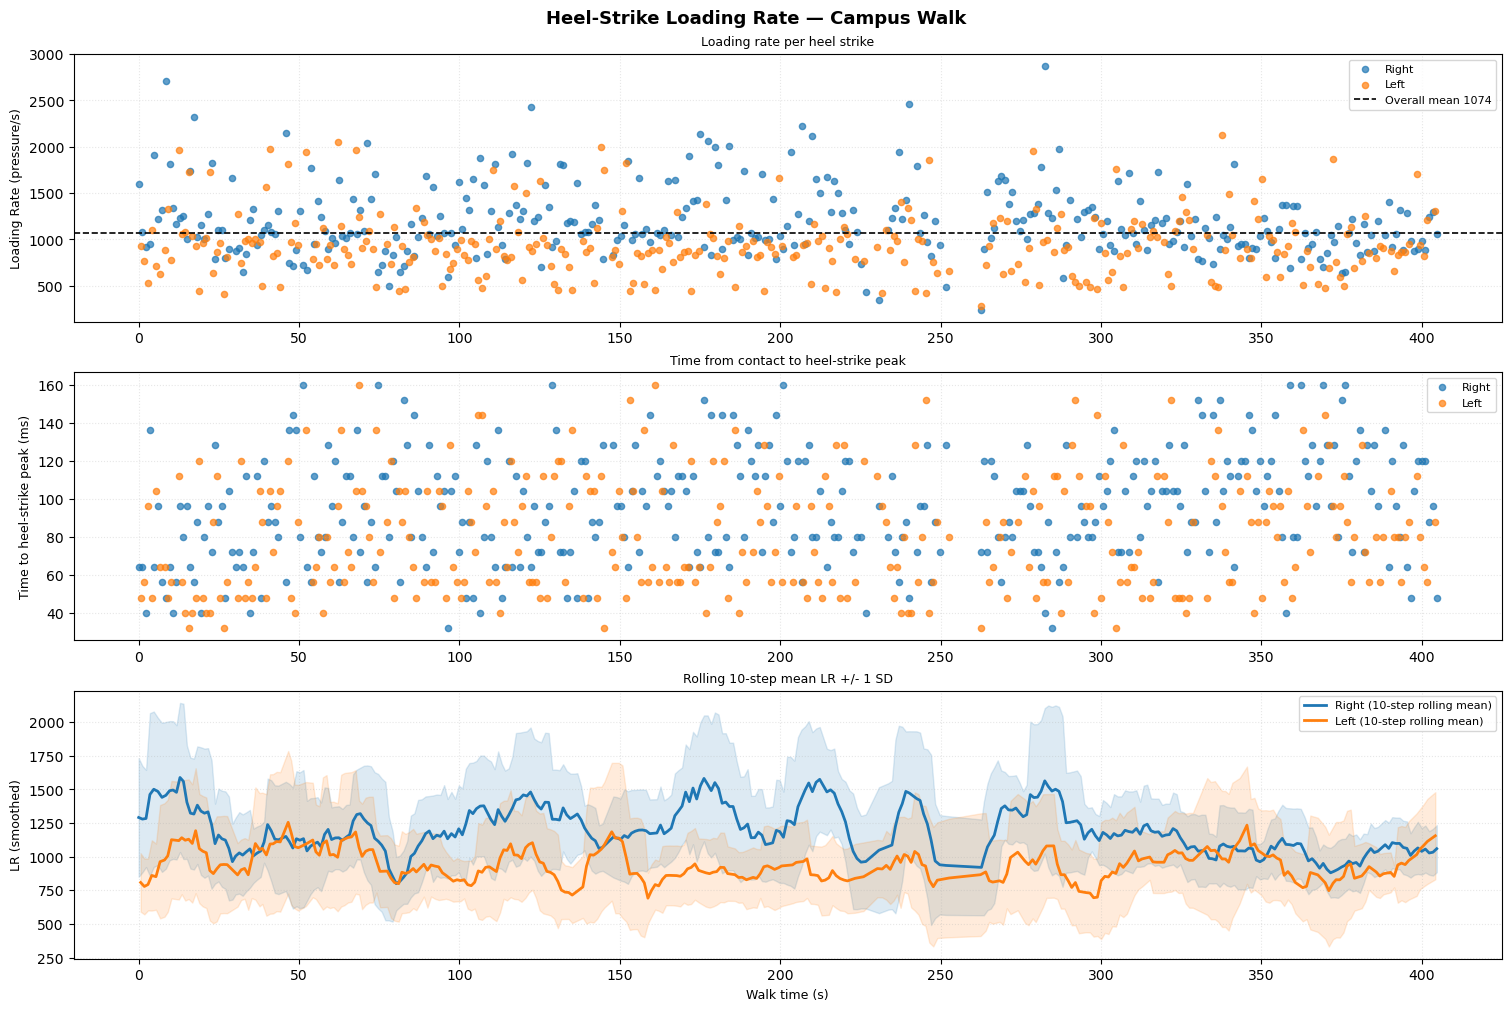

Saved -> lr_over_time.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), constrained_layout=True)
fig.suptitle('Heel-Strike Loading Rate — Campus Walk', fontsize=13, fontweight='bold')

for foot in ['right', 'left']:
    fd = all_steps[all_steps['foot'] == foot]
    axes[0].scatter(fd['walk_time_s'], fd['loading_rate'],
                    c=FOOT_COLORS[foot], label=foot.capitalize(), s=20, alpha=0.7)
axes[0].axhline(all_steps['loading_rate'].mean(), color='black', ls='--', lw=1.2,
                label=f'Overall mean {all_steps["loading_rate"].mean():.0f}')
axes[0].set_ylabel('Loading Rate (pressure/s)', fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, ls=':')
axes[0].set_title('Loading rate per heel strike', fontsize=9)

for foot in ['right', 'left']:
    fd = all_steps[all_steps['foot'] == foot]
    axes[1].scatter(fd['walk_time_s'], fd['time_to_peak_sec'] * 1000,
                    c=FOOT_COLORS[foot], label=foot.capitalize(), s=20, alpha=0.7)
axes[1].set_ylabel('Time to heel-strike peak (ms)', fontsize=9)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, ls=':')
axes[1].set_title('Time from contact to heel-strike peak', fontsize=9)

for foot in ['right', 'left']:
    fd     = all_steps[all_steps['foot'] == foot].sort_values('walk_time_s')
    rolled = fd['loading_rate'].rolling(10, center=True, min_periods=3)
    axes[2].plot(fd['walk_time_s'], rolled.mean(),
                 color=FOOT_COLORS[foot], lw=2,
                 label=f'{foot.capitalize()} (10-step rolling mean)')
    axes[2].fill_between(fd['walk_time_s'],
                         rolled.mean() - rolled.std(),
                         rolled.mean() + rolled.std(),
                         alpha=0.15, color=FOOT_COLORS[foot])
axes[2].set_xlabel('Walk time (s)', fontsize=9)
axes[2].set_ylabel('LR (smoothed)', fontsize=9)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, ls=':')
axes[2].set_title('Rolling 10-step mean LR +/- 1 SD', fontsize=9)

plt.savefig('lr_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> lr_over_time.png')

## Cell 11 — Distribution Plots

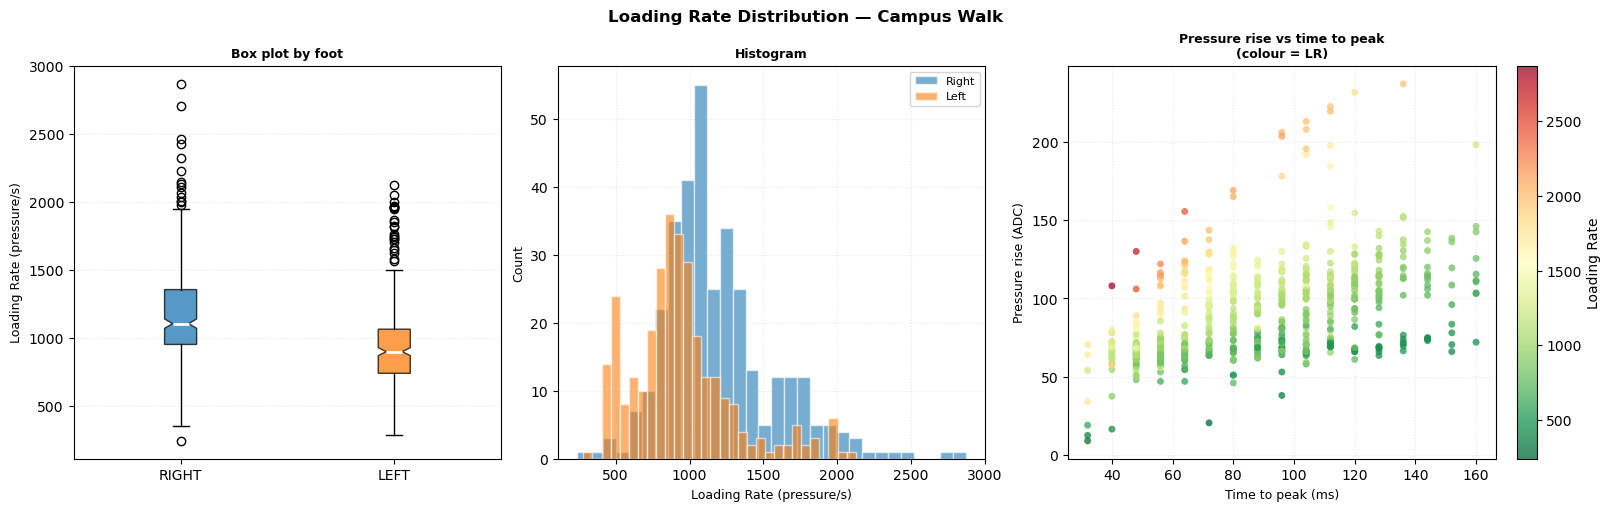

Saved -> lr_distribution.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Loading Rate Distribution — Campus Walk', fontsize=12, fontweight='bold')

groups = [all_steps[all_steps['foot'] == f]['loading_rate'].values
          for f in ['right', 'left']]
bp = axes[0].boxplot(groups, patch_artist=True, notch=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, foot in zip(bp['boxes'], ['right', 'left']):
    patch.set_facecolor(FOOT_COLORS[foot]); patch.set_alpha(0.75)
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(['RIGHT', 'LEFT'])
axes[0].set_ylabel('Loading Rate (pressure/s)', fontsize=9)
axes[0].set_title('Box plot by foot', fontsize=9, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y', ls=':')

for foot in ['right', 'left']:
    fd = all_steps[all_steps['foot'] == foot]['loading_rate']
    axes[1].hist(fd, bins=30, color=FOOT_COLORS[foot],
                 alpha=0.6, label=foot.capitalize(), edgecolor='white')
axes[1].set_xlabel('Loading Rate (pressure/s)', fontsize=9)
axes[1].set_ylabel('Count', fontsize=9)
axes[1].set_title('Histogram', fontsize=9, fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, ls=':')

sc = axes[2].scatter(
    all_steps['time_to_peak_sec'] * 1000,
    all_steps['pressure_rise'],
    c=all_steps['loading_rate'], cmap='RdYlGn_r',
    s=25, alpha=0.75, edgecolors='none')
plt.colorbar(sc, ax=axes[2], label='Loading Rate')
axes[2].set_xlabel('Time to peak (ms)', fontsize=9)
axes[2].set_ylabel('Pressure rise (ADC)', fontsize=9)
axes[2].set_title('Pressure rise vs time to peak\n(colour = LR)', fontsize=9, fontweight='bold')
axes[2].grid(True, alpha=0.3, ls=':')

plt.savefig('lr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> lr_distribution.png')

## Cell 12 — Export CSV

In [12]:
export_cols = [
    'foot', 'step_id',
    'contact_time_sec', 'peak_time_sec', 'walk_time_s',
    'contact_pressure', 'peak_pressure',
    'pressure_rise', 'time_to_peak_sec', 'loading_rate',
    'n_sensors', 'contact_timestamp', 'lat', 'lon',
]
export_df = all_steps[[c for c in export_cols if c in all_steps.columns]].copy()
export_df.to_csv('campus_loading_rates.csv', index=False)
print(f'Saved -> campus_loading_rates.csv  ({export_df.shape[0]} rows x {export_df.shape[1]} cols)')
try:
    display(export_df.head(6))
except NameError:
    print(export_df.head(6).to_string())

Saved -> campus_loading_rates.csv  (642 rows x 14 cols)


,foot,step_id,contact_time_sec,peak_time_sec,walk_time_s,contact_pressure,peak_pressure,pressure_rise,time_to_peak_sec,loading_rate,n_sensors,contact_timestamp,lat,lon
0,left,1,4.160,4.208,0.608,142.5,203.0,60.5,0.048,931.250000,2,1777057751104,42.336983,-71.090606
1,left,2,5.320,5.376,1.768,143.5,200.5,57.0,0.056,768.750000,2,1777057752264,42.336989,-71.090607
2,left,3,6.456,6.552,2.904,139.0,207.5,68.5,0.096,531.250000,2,1777057753400,42.336998,-71.090614
3,left,4,7.632,7.680,4.080,157.5,223.5,66.0,0.048,1100.000000,2,1777057754576,42.337002,-71.090650
4,left,5,8.944,9.048,5.392,144.5,202.5,58.0,0.104,708.593750,2,1777057755888,42.337009,-71.090664
5,left,6,10.224,10.288,6.672,149.0,203.5,54.5,0.064,630.208333,2,1777057757168,42.337014,-71.090676


## Cell 13 — Colour-Scale Setup

Loading rate is mapped to a **reversed RdYlGn** scale:
- Red   = high LR (fast, hard heel strike)
- Green = low LR  (gradual, compliant strike)

The scale is clipped to **p5–p95** to prevent a few extreme outliers
from washing out colour contrast across the rest of the route.

Colour scale: 493 (p5 = green/low) -> 1820 (p95 = red/high)


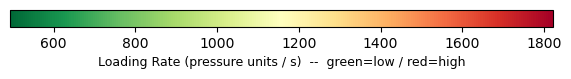

In [13]:
lr_p05 = all_steps['loading_rate'].quantile(0.05)
lr_p95 = all_steps['loading_rate'].quantile(0.95)
print(f'Colour scale: {lr_p05:.0f} (p5 = green/low) -> {lr_p95:.0f} (p95 = red/high)')

def lr_to_hex(lr, vmin=None, vmax=None):
    if vmin is None: vmin = lr_p05
    if vmax is None: vmax = lr_p95
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    rgba = cm.RdYlGn_r(norm(float(np.clip(lr, vmin, vmax))))
    return mcolors.to_hex(rgba)

fig, ax = plt.subplots(figsize=(7, 0.6))
fig.subplots_adjust(bottom=0.6)
cb = plt.colorbar(
    cm.ScalarMappable(norm=mcolors.Normalize(lr_p05, lr_p95), cmap='RdYlGn_r'),
    cax=ax, orientation='horizontal')
cb.set_label('Loading Rate (pressure units / s)  --  green=low / red=high', fontsize=9)
plt.savefig('lr_colorbar.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 14 — Folium Map 1: Route Coloured by Loading Rate

The GPS route is drawn as **coloured polyline segments** where each segment's
colour reflects the loading rate of the nearest heel strike in time.
Every matched step also gets a **circle marker** — click it for the full
per-step stats popup.

In [14]:
centre_lat = gpx_df['lat'].mean()
centre_lon = gpx_df['lon'].mean()
steps_ok   = all_steps.dropna(subset=['lat', 'lon']).copy()

m = folium.Map(location=[centre_lat, centre_lon], zoom_start=17,
               tiles='CartoDB positron')

# Grey background polyline
route_coords = list(zip(gpx_df['lat'], gpx_df['lon']))
folium.PolyLine(route_coords, color='#bbbbbb', weight=3,
                opacity=0.5, tooltip='GPS route').add_to(m)

# Interpolate LR onto every GPX point
gpx_with_lr = pd.merge_asof(
    gpx_df.sort_values('unix_ms'),
    steps_ok[['contact_timestamp', 'loading_rate']]
        .sort_values('contact_timestamp')
        .rename(columns={'contact_timestamp': 'unix_ms'}),
    on='unix_ms', direction='nearest', tolerance=GPS_TOLERANCE_MS,
).fillna({'loading_rate': all_steps['loading_rate'].mean()})

# Coloured segments
for i in range(len(gpx_with_lr) - 1):
    r0 = gpx_with_lr.iloc[i]
    r1 = gpx_with_lr.iloc[i + 1]
    folium.PolyLine(
        [(r0['lat'], r0['lon']), (r1['lat'], r1['lon'])],
        color=lr_to_hex((r0['loading_rate'] + r1['loading_rate']) / 2),
        weight=6, opacity=0.85
    ).add_to(m)

# Per-step markers
for _, row in steps_ok.iterrows():
    color = lr_to_hex(row['loading_rate'])
    popup_html = (
        f"<div style='font-family:Arial; font-size:12px; min-width:210px;'>"
        f"<b style='color:{color};'>{row['foot'].upper()} Step {int(row['step_id'])}</b><br>"
        f"<table style='border-collapse:collapse; width:100%;'>"
        f"<tr style='background:#f5f5f5'><td><b>Loading rate</b></td>"
        f"<td><b>{row['loading_rate']:.0f}</b> pressure/s</td></tr>"
        f"<tr><td>Pressure rise</td><td>{row['pressure_rise']:.1f} ADC</td></tr>"
        f"<tr style='background:#f5f5f5'><td>Time to peak</td>"
        f"<td>{row['time_to_peak_sec']*1000:.1f} ms</td></tr>"
        f"<tr><td>Contact pressure</td><td>{row['contact_pressure']:.1f}</td></tr>"
        f"<tr style='background:#f5f5f5'><td>Peak pressure</td>"
        f"<td>{row['peak_pressure']:.1f}</td></tr>"
        f"<tr><td>Sensors averaged</td><td>{int(row['n_sensors'])}</td></tr>"
        f"<tr style='background:#f5f5f5'><td>Walk time</td>"
        f"<td>{row['walk_time_s']:.1f} s</td></tr>"
        f"</table></div>"
    )
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5, color=color, fill=True, fill_color=color,
        fill_opacity=0.85, weight=1,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=(f"{row['foot'].upper()} step {int(row['step_id'])} | "
                 f"LR={row['loading_rate']:.0f} | "
                 f"rise={row['pressure_rise']:.1f} | "
                 f"dt={row['time_to_peak_sec']*1000:.1f} ms")
    ).add_to(m)

folium.Marker([gpx_df['lat'].iloc[0],  gpx_df['lon'].iloc[0]],
              icon=folium.Icon(color='green', icon='play',  prefix='fa'),
              tooltip='Walk start').add_to(m)
folium.Marker([gpx_df['lat'].iloc[-1], gpx_df['lon'].iloc[-1]],
              icon=folium.Icon(color='red',   icon='stop',  prefix='fa'),
              tooltip='Walk end').add_to(m)

legend_html = (
    f"<div style='position:fixed; bottom:30px; left:30px; z-index:1000; "
    f"background:white; padding:12px 16px; border-radius:8px; "
    f"box-shadow:0 2px 8px rgba(0,0,0,0.25); font-family:Arial; font-size:12px;'>"
    f"<b style='font-size:13px;'>Heel-Strike Loading Rate</b><br>"
    f"<span style='color:#d73027;'>&#9679;</span> High LR (fast, hard heel load)<br>"
    f"<span style='color:#fee08b;'>&#9679;</span> Moderate<br>"
    f"<span style='color:#1a9850;'>&#9679;</span> Low LR (gradual, compliant strike)<br>"
    f"<hr style='margin:6px 0;'>"
    f"Scale: {lr_p05:.0f} - {lr_p95:.0f} pressure/s<br>"
    f"<i style='font-size:11px;'>Route colour = nearest step LR</i><br>"
    f"<i style='font-size:11px;'>Dots = heel strikes (click for details)</i>"
    f"</div>"
)
m.get_root().html.add_child(folium.Element(legend_html))

m.save('campus_lr_map.html')
print('Map saved -> campus_lr_map.html')
m

Map saved -> campus_lr_map.html


## Cell 15 — Folium Map 2: Right / Left Foot as Toggleable Layers

Same coloured route, but step markers are split into **RIGHT** and **LEFT** foot
`FeatureGroup` layers — toggle each foot via the layer control (top-right).

Marker **ring** = foot identity (blue=right, orange=left)  
Marker **fill** = loading rate (green=low, red=high)

In [15]:
m2 = folium.Map(location=[centre_lat, centre_lon], zoom_start=17,
                tiles='CartoDB positron')

folium.PolyLine(route_coords, color='#cccccc', weight=3, opacity=0.5).add_to(m2)

route_fg = folium.FeatureGroup(name='Route (LR colour)', show=True)
for i in range(len(gpx_with_lr) - 1):
    r0 = gpx_with_lr.iloc[i]; r1 = gpx_with_lr.iloc[i + 1]
    folium.PolyLine(
        [(r0['lat'], r0['lon']), (r1['lat'], r1['lon'])],
        color=lr_to_hex((r0['loading_rate'] + r1['loading_rate']) / 2),
        weight=6, opacity=0.85
    ).add_to(route_fg)
route_fg.add_to(m2)

for foot in ['right', 'left']:
    fg       = folium.FeatureGroup(name=f'{foot.capitalize()} foot', show=True)
    ring_col = FOOT_COLORS[foot]
    for _, row in steps_ok[steps_ok['foot'] == foot].iterrows():
        fill_col = lr_to_hex(row['loading_rate'])
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6, color=ring_col, fill=True,
            fill_color=fill_col, fill_opacity=0.9, weight=2,
            popup=folium.Popup(
                f"<b>{foot.upper()} step {int(row['step_id'])}</b><br>"
                f"LR: <b>{row['loading_rate']:.0f}</b> pressure/s<br>"
                f"Pressure rise: {row['pressure_rise']:.1f} ADC<br>"
                f"Time to peak: {row['time_to_peak_sec']*1000:.1f} ms<br>"
                f"Walk time: {row['walk_time_s']:.1f} s",
                max_width=200),
            tooltip=(f"{foot.upper()} step {int(row['step_id'])} | "
                     f"LR={row['loading_rate']:.0f} | "
                     f"dt={row['time_to_peak_sec']*1000:.1f} ms")
        ).add_to(fg)
    fg.add_to(m2)

folium.Marker([gpx_df['lat'].iloc[0],  gpx_df['lon'].iloc[0]],
              icon=folium.Icon(color='green', icon='play',  prefix='fa'),
              tooltip='Walk start').add_to(m2)
folium.Marker([gpx_df['lat'].iloc[-1], gpx_df['lon'].iloc[-1]],
              icon=folium.Icon(color='red',   icon='stop',  prefix='fa'),
              tooltip='Walk end').add_to(m2)

legend2_html = (
    f"<div style='position:fixed; bottom:30px; left:30px; z-index:1000; "
    f"background:white; padding:12px 16px; border-radius:8px; "
    f"box-shadow:0 2px 8px rgba(0,0,0,0.25); font-family:Arial; font-size:12px;'>"
    f"<b style='font-size:13px;'>Loading Rate (fill colour)</b><br>"
    f"<span style='color:#d73027;'>&#9679;</span> High LR<br>"
    f"<span style='color:#fee08b;'>&#9679;</span> Moderate<br>"
    f"<span style='color:#1a9850;'>&#9679;</span> Low LR<br>"
    f"<hr style='margin:6px 0;'>"
    f"<b>Ring = foot identity</b><br>"
    f"<span style='color:{FOOT_COLORS['right']};'>&#11044;</span> Right foot<br>"
    f"<span style='color:{FOOT_COLORS['left']};'>&#11044;</span> Left foot<br>"
    f"<hr style='margin:6px 0;'>"
    f"<i style='font-size:11px;'>Use layer control (top right) to toggle feet</i>"
    f"</div>"
)
m2.get_root().html.add_child(folium.Element(legend2_html))
folium.LayerControl(collapsed=False).add_to(m2)

m2.save('campus_lr_detail_map.html')
print('Detail map saved -> campus_lr_detail_map.html')
m2

Detail map saved -> campus_lr_detail_map.html
